<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/CNN/CNN_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical

# --- Paths ---
image_folder = "/content/drive/MyDrive/AI-python/CNN_testing/image_train_data"
attribute_file = "/content/drive/MyDrive/AI-python/CNN_testing/list_attr_celeba.xlsx"
models_folder = "/content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads"
os.makedirs(models_folder, exist_ok=True)

# --- Load attributes ---
df = pd.read_excel(attribute_file)
df = df.replace(-1,0)
df.iloc[:,1:] = df.iloc[:,1:].apply(pd.to_numeric, errors='coerce')
attributes = df.columns[1:]

# --- Load & preprocess images ---
images = []
for i in range(len(df)):
    img_name = df.iloc[i,0]
    img_path = os.path.join(image_folder,img_name)

    img = Image.open(img_path).convert("L")
    img = img.resize((64,64))
    img_array = np.array(img)/255.0
    img_array = img_array.reshape(64,64,1)
    images.append(img_array)

X = np.array(images, dtype="float32")

# --- Shared convolutional base ---
inputs = Input(shape=(64,64,1))
x = Conv2D(32,(3,3), activation='relu')(inputs)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64,(3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)

# --- Train each softmax head separately ---
from sklearn.model_selection import train_test_split

for attr in attributes:
    print(f"\nTraining attribute: {attr}")

    # Labels
    y_attr = to_categorical(df[attr].values, num_classes=2)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_attr, test_size=0.2, random_state=42
    )

    # Create small model: shared base -> softmax head
    head = Dense(2, activation='softmax', name=attr)(x)
    model = Model(inputs=inputs, outputs=head)

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        validation_split=0.1
    )

    # Save this attribute model
    model_path = os.path.join(models_folder, f"{attr}_softmax_cnn.h5")
    model.save(model_path)
    print(f"Saved model for {attr} at {model_path}")


Training attribute: 5_o_Clock_Shadow
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.8646 - loss: 0.4257 - val_accuracy: 0.8750 - val_loss: 0.3682
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.8785 - loss: 0.3413 - val_accuracy: 0.8750 - val_loss: 0.3649
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 191ms/step - accuracy: 0.8806 - loss: 0.3107 - val_accuracy: 0.8750 - val_loss: 0.3526
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.8944 - loss: 0.2628 - val_accuracy: 0.8875 - val_loss: 0.3256
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.9111 - loss: 0.2304 - val_accuracy: 0.8625 - val_loss: 0.3230
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.9104 - loss: 0.2190 - val_accuracy: 0.9062 - val_loss: 0.3429
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.9326 - loss: 0.1685 - val_accuracy: 0.9000 - val_loss: 0.3729
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0

Saved model for 5_o_Clock_Shadow at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/5_o_Clock_Shadow_softmax_cnn.h5

Training attribute: Arched_Eyebrows
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.7451 - loss: 0.5452 - val_accuracy: 0.7437 - val_loss: 0.4920
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 189ms/step - accuracy: 0.8076 - loss: 0.4248 - val_accuracy: 0.7812 - val_loss: 0.4203
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.8271 - loss: 0.3670 - val_accuracy: 0.7625 - val_loss: 0.4295
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 144ms/step - accuracy: 0.8674 - loss: 0.3091 - val_accuracy: 0.7688 - val_loss: 0.4300
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 190ms/step - accuracy: 0.8813 - loss: 0.2831 - val_accuracy: 0.7188 - val_loss: 0.5419
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.8931 - loss: 0.2472 - val_accuracy: 0.7875 - val_loss: 0.4776
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy:

Saved model for Arched_Eyebrows at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Arched_Eyebrows_softmax_cnn.h5

Training attribute: Attractive
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.6701 - loss: 0.6602 - val_accuracy: 0.7063 - val_loss: 0.5638
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.7646 - loss: 0.5017 - val_accuracy: 0.7500 - val_loss: 0.5264
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.8118 - loss: 0.4205 - val_accuracy: 0.7437 - val_loss: 0.5381
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.8562 - loss: 0.3347 - val_accuracy: 0.6938 - val_loss: 0.5742
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step - accuracy: 0.9132 - loss: 0.2406 - val_accuracy: 0.7250 - val_loss: 0.6250
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 162ms/step - accuracy: 0.9479 - loss: 0.1641 - val_accuracy: 0.7000 - val_loss: 0.7103
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step - accuracy: 0.9806

Saved model for Attractive at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Attractive_softmax_cnn.h5

Training attribute: Bags_Under_Eyes
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.7583 - loss: 0.6290 - val_accuracy: 0.7563 - val_loss: 0.5075
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 180ms/step - accuracy: 0.8146 - loss: 0.3933 - val_accuracy: 0.7688 - val_loss: 0.5139
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.8694 - loss: 0.3086 - val_accuracy: 0.7812 - val_loss: 0.5058
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.9069 - loss: 0.2227 - val_accuracy: 0.7563 - val_loss: 0.5568
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 187ms/step - accuracy: 0.9382 - loss: 0.1689 - val_accuracy: 0.7750 - val_loss: 0.6174
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.9750 - loss: 0.0997 - val_accuracy: 0.7750 - val_loss: 0.6975
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.9937 - l

Saved model for Bags_Under_Eyes at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Bags_Under_Eyes_softmax_cnn.h5

Training attribute: Bald
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.9340 - loss: 0.4518 - val_accuracy: 0.9625 - val_loss: 0.2816
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.9764 - loss: 0.1211 - val_accuracy: 0.9625 - val_loss: 0.2387
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 154ms/step - accuracy: 0.9785 - loss: 0.0764 - val_accuracy: 0.9625 - val_loss: 0.2135
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - accuracy: 0.9819 - loss: 0.0458 - val_accuracy: 0.9625 - val_loss: 0.2244
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.9889 - loss: 0.0258 - val_accuracy: 0.9625 - val_loss: 0.2130
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 192ms/step - accuracy: 0.9972 - loss: 0.0132 - val_accuracy: 0.9625 - val_loss: 0.2825
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.9986 - lo

...

Saved model for Wearing_Hat at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Wearing_Hat_softmax_cnn.h5

Training attribute: Wearing_Lipstick
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.7549 - loss: 0.6956 - val_accuracy: 0.8313 - val_loss: 0.4612
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step - accuracy: 0.9090 - loss: 0.2347 - val_accuracy: 0.8188 - val_loss: 0.4475
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 160ms/step - accuracy: 0.9625 - loss: 0.1211 - val_accuracy: 0.8375 - val_loss: 0.4960
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - accuracy: 0.9868 - loss: 0.0565 - val_accuracy: 0.8438 - val_loss: 0.5157
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 158ms/step - accuracy: 0.9937 - loss: 0.0270 - val_accuracy: 0.8313 - val_loss: 0.5885
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.9979 - loss: 0.0135 - val_accuracy: 0.8125 - val_loss: 0.6516
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 184ms/step - accuracy: 0.9986

Saved model for Wearing_Lipstick at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Wearing_Lipstick_softmax_cnn.h5

Training attribute: Wearing_Necklace
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 172ms/step - accuracy: 0.8326 - loss: 0.6885 - val_accuracy: 0.8250 - val_loss: 0.5385
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8903 - loss: 0.2834 - val_accuracy: 0.8188 - val_loss: 0.4970
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - accuracy: 0.9333 - loss: 0.1820 - val_accuracy: 0.8313 - val_loss: 0.5539
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.9604 - loss: 0.1125 - val_accuracy: 0.8250 - val_loss: 0.6728
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.9826 - loss: 0.0606 - val_accuracy: 0.8188 - val_loss: 0.7393
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 186ms/step - accuracy: 0.9931 - loss: 0.0318 - val_accuracy: 0.8188 - val_loss: 0.8106
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accura

Saved model for Wearing_Necklace at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Wearing_Necklace_softmax_cnn.h5

Training attribute: Wearing_Necktie
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 192ms/step - accuracy: 0.8813 - loss: 0.5666 - val_accuracy: 0.9375 - val_loss: 0.3175
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step - accuracy: 0.9403 - loss: 0.1682 - val_accuracy: 0.9438 - val_loss: 0.2993
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.9708 - loss: 0.0766 - val_accuracy: 0.9312 - val_loss: 0.3249
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.9910 - loss: 0.0334 - val_accuracy: 0.9312 - val_loss: 0.3781
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 165ms/step - accuracy: 0.9986 - loss: 0.0147 - val_accuracy: 0.9375 - val_loss: 0.4188
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 148ms/step - accuracy: 0.9993 - loss: 0.0073 - val_accuracy: 0.9375 - val_loss: 0.4276
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accur

Saved model for Wearing_Necktie at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Wearing_Necktie_softmax_cnn.h5

Training attribute: Young
Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.7306 - loss: 0.8752 - val_accuracy: 0.7375 - val_loss: 0.6986
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.8285 - loss: 0.4150 - val_accuracy: 0.7250 - val_loss: 0.6602
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.8931 - loss: 0.2659 - val_accuracy: 0.7000 - val_loss: 0.6954
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.9382 - loss: 0.1753 - val_accuracy: 0.7000 - val_loss: 0.7619
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 186ms/step - accuracy: 0.9667 - loss: 0.1088 - val_accuracy: 0.6812 - val_loss: 0.8521
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 143ms/step - accuracy: 0.9840 - loss: 0.0644 - val_accuracy: 0.6875 - val_loss: 0.9186
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step - accuracy: 0.9944 - lo

Saved model for Young at /content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads/Young_softmax_cnn.h5


Loading all 40 models into memory...


Images preprocessed: (10, 64, 64, 1)


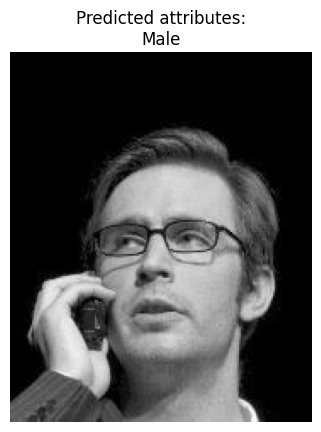

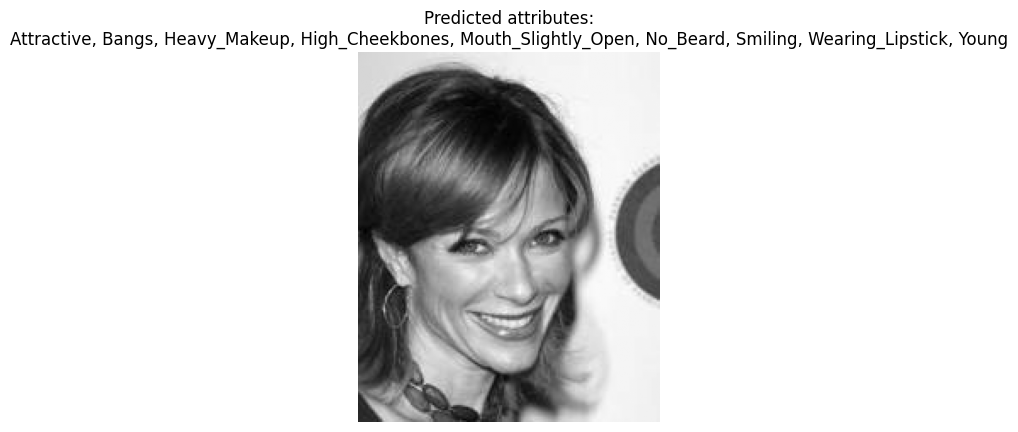

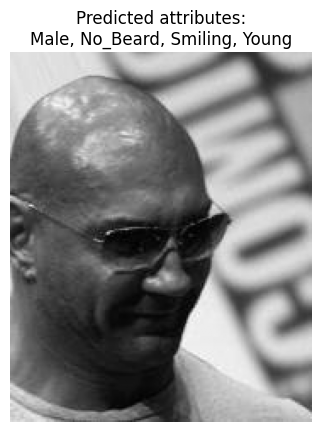

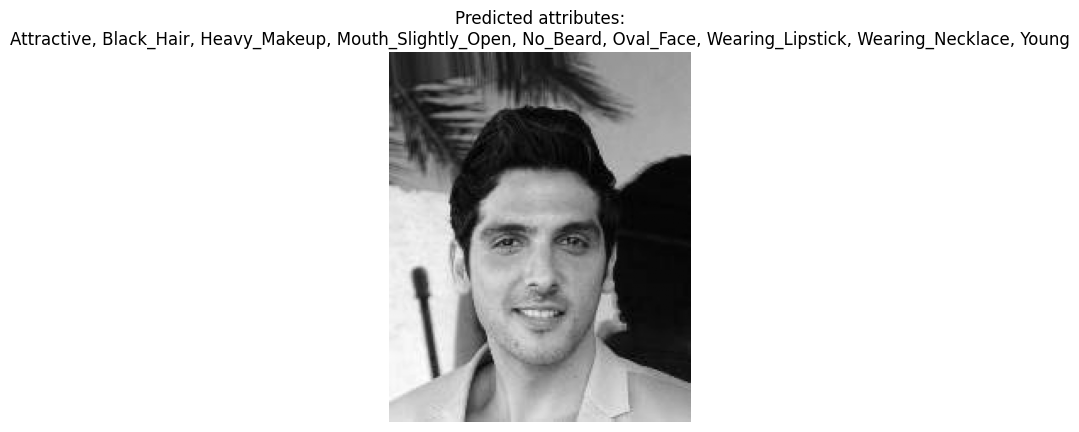

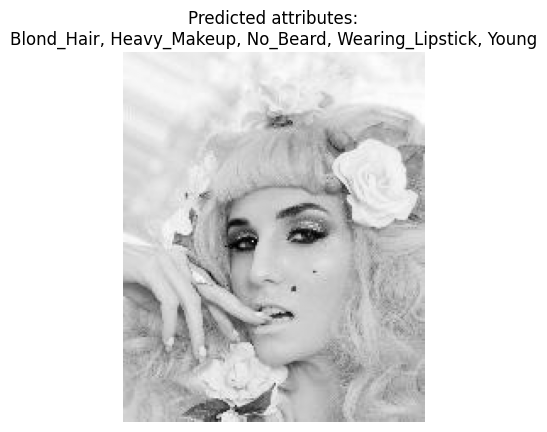

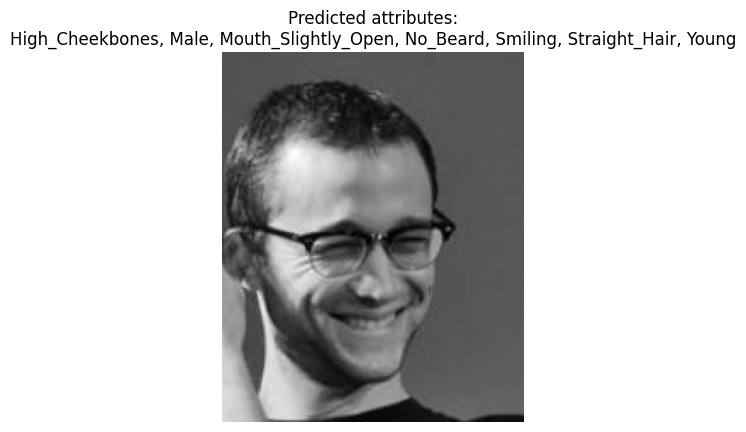

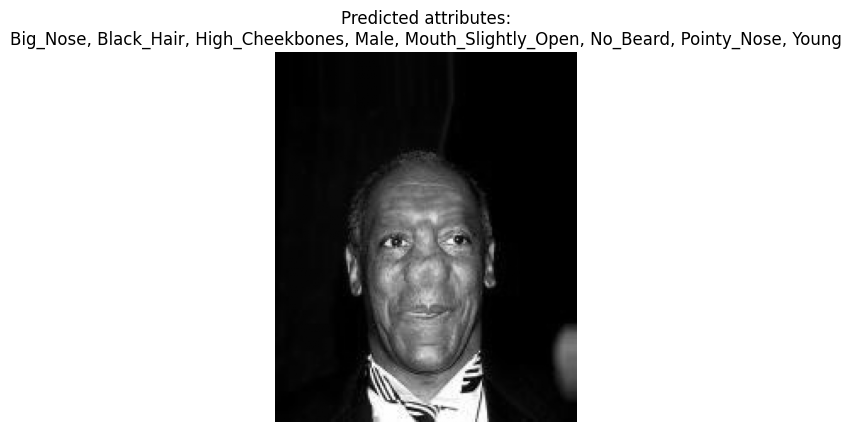

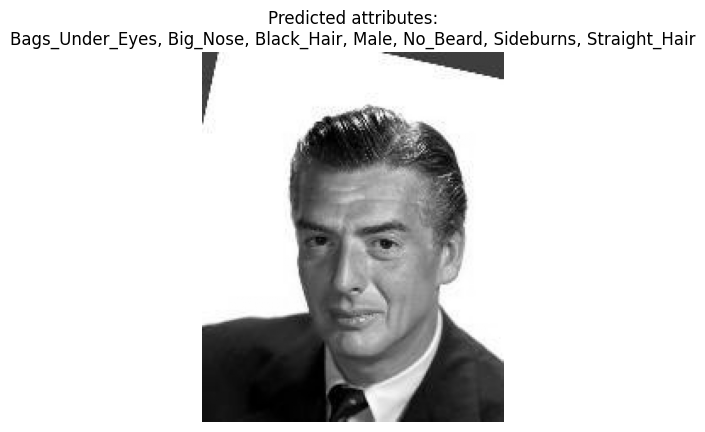

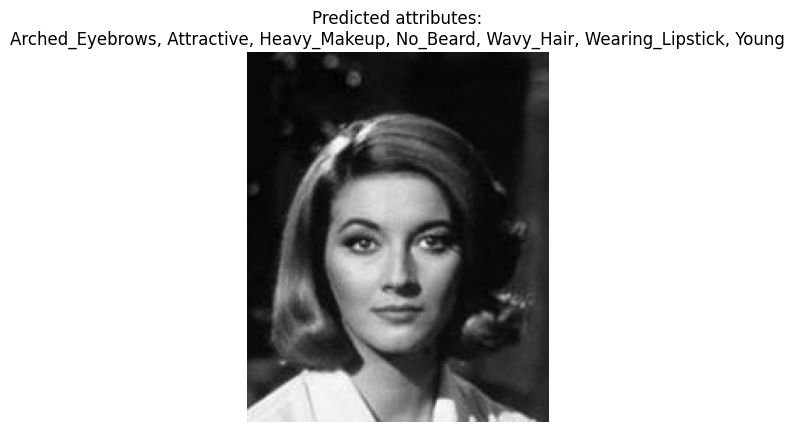

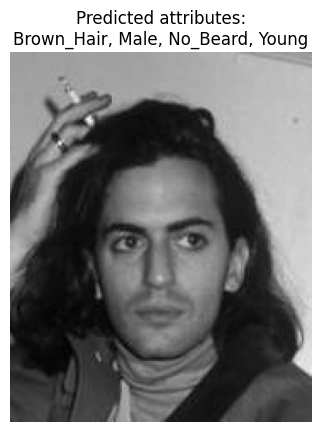

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# --- Paths ---
models_folder = "/content/drive/MyDrive/AI-python/CNN_testing/softmax_cnn_heads"
image_folder = "/content/drive/MyDrive/AI-python/CNN_testing/image_test_data"  # folder with my 10 test images

# --- Get attribute names and model paths ---
attribute_files = [f for f in os.listdir(models_folder) if f.endswith(".h5")]
attributes = [f.replace("_softmax_cnn.h5","") for f in attribute_files]
model_paths = {attr: os.path.join(models_folder, f"{attr}_softmax_cnn.h5") for attr in attributes}

# --- Load all models once ---
print("Loading all 40 models into memory...")
models = {attr: load_model(path) for attr, path in model_paths.items()}

# --- Load and preprocess all images ---
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder)
               if f.lower().endswith(('.png','.jpg','.jpeg'))][:10]

images = []
original_images = []
for img_path in image_files:
    img = Image.open(img_path).convert("L")
    original_images.append(img.copy())  # keep original for display
    img_resized = img.resize((64,64))
    img_array = np.array(img_resized)/255.0
    img_array = img_array.reshape(64,64,1)
    images.append(img_array)

X_test = np.array(images, dtype="float32")
print("Images preprocessed:", X_test.shape)

# --- Predict all attributes for each image ---
for idx, img_array in enumerate(X_test):
    img_array_batch = img_array.reshape(1,64,64,1)
    predicted_attributes = []

    for attr in attributes:
        pred = models[attr].predict(img_array_batch, verbose=0)
        label = np.argmax(pred)
        if label == 1:
            predicted_attributes.append(attr)

    # Display image with predicted attributes
    plt.imshow(original_images[idx], cmap='gray')
    plt.axis('off')
    plt.title("Predicted attributes:\n" + ", ".join(predicted_attributes))
    plt.show()